### 0.3 Plotting the eRASS sky and exploring HEALpy

This notebook explores the use of HEALPy with eROSITA-DE all sky survey data.


**Author**: Soumya Shreeram <br/>
**Date created**: 25th April 2022 <br/>
**Last edited**: tbu <br/>

In [94]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits

from astropy.table import Table, Column, join
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, z_at_value

import numpy as np

# system imports
import os
import sys
import importlib as ib
import glob
import gzip

# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

import seaborn as sns

from scipy.stats import norm
from scipy import interpolate
import pandas as pd

import healpy as hp

In [10]:
import filaments as fo

In [2]:
matplotlib.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 16}
matplotlib.rc('font', **font)

bright_colors = sns.color_palette("bright")

In [3]:
base_dir = "/data53s/shreeram/Filament_stacking"
code_dir = f"{base_dir}/code"
image_dir = f"{base_dir}/images"
data_dir = f"{base_dir}/data"

In [ ]:
mapexp,header=hp.read_map(f'{data_dir}/Map_eRASS1_ImageTot_band021_947.fits.gz', h=True, verbose=True)
def getval(ra,dec):
    theta = 0.5 * np.pi - np.deg2rad(dec)
    phi = np.deg2rad(ra)
    ipix = hp.ang2pix(4096, theta, phi)
    val=mapexp[ipix]
    if val==0:
        val=1e-8
    return val

nlon, nlat = 1801, 901   
lon = np.linspace(-np.pi, np.pi, num=nlon)
lat = np.linspace(-np.pi/2., np.pi/2., num=nlat)
grid_lon, grid_lat = np.meshgrid(lon, lat)
coords = SkyCoord(ra=grid_lon, dec=grid_lat, unit='rad', frame='icrs')
print(coords.shape)
nrows, ncols = coords.shape
val = [[getval(lon[j]/np.pi*180,lat[i]/np.pi*180) for j in range(ncols)] for i in range(nrows)]

grid_lon_new=grid_lon
for i in range(grid_lon.shape[0]):
    for j in range(grid_lon.shape[1]):
        if grid_lon[i,j]>np.pi:
            grid_lon_new[i,j]=-1*((grid_lon[i,j] % np.pi) - np.pi)
        else:
            grid_lon_new[i,j]=-1*grid_lon[i,j]

In [75]:
def plot_eRASS_skymap(fig, ax, grid_lon_new, grid_lat, cmap='Greys', vmin=1e-2, vmax=1,\
                     shading='auto', alpha=1):
    norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax)
            
    im = ax.pcolormesh(grid_lon_new, grid_lat, val, cmap=cmap, shading=shading,
                       vmin=vmin, vmax=vmax, antialiased=True, alpha=alpha)
    ax.grid(True)
    ax.set_xlabel('R.A.')
    ax.set_ylabel('Dec.')
    return ax, fig 

In [101]:
def set_as_white(ax):
    ax.yaxis.label.set_color('w')
    ax.xaxis.label.set_color('w')

    ax.tick_params(axis='x', colors='w', which='both')
    ax.tick_params(axis='y', colors='w', which='both')
    return ax 

<MollweideAxesSubplot:xlabel='R.A.', ylabel='Dec.'>

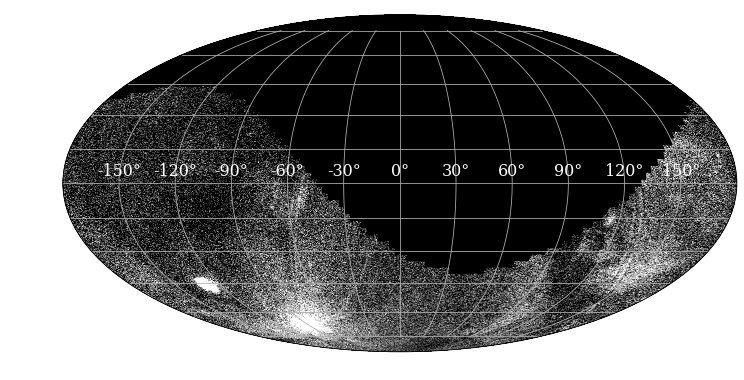

In [102]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")
ax, fig = plot_eRASS_skymap(fig, ax, grid_lon_new, grid_lat, cmap='Greys_r')
set_as_white(ax)

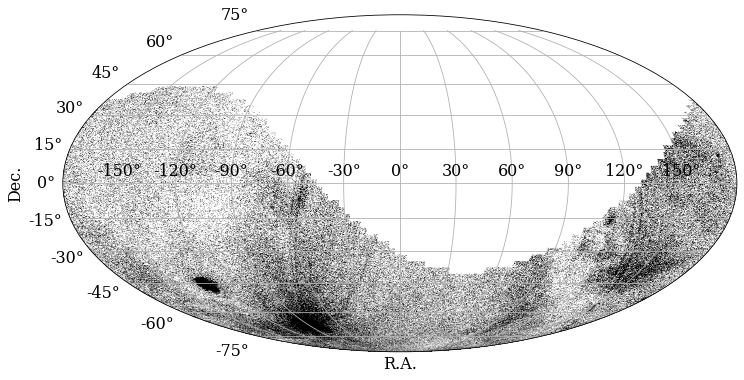

In [70]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")
ax, fig = plot_eRASS_skymap(fig, ax, grid_lon_new, grid_lat, shading='gouraud')
fig.patch.set_facecolor('white')

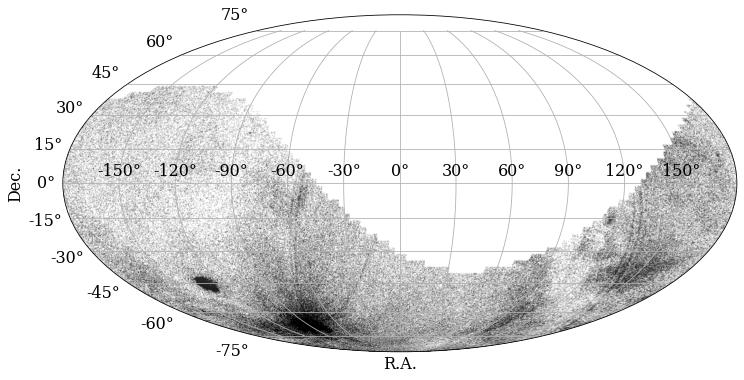

In [77]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")
ax, fig = plot_eRASS_skymap(fig, ax, grid_lon_new, grid_lat,shading='nearest', alpha=0.1)
fig.patch.set_facecolor('white')

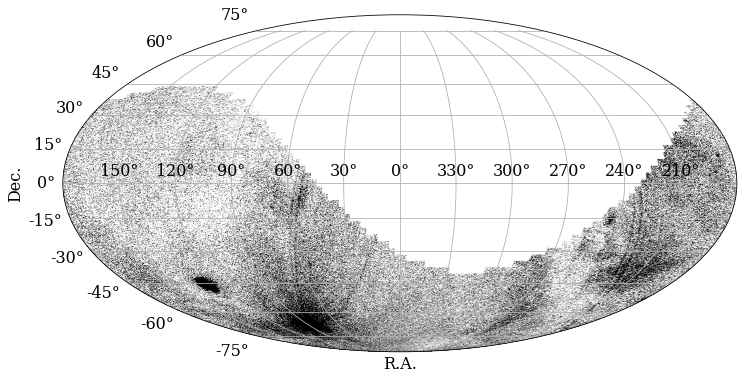

In [76]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")
ax, fig = plot_eRASS_skymap(fig, ax, grid_lon_new, grid_lat, alpha=0.5)
plt.xticks(ticks=np.radians([-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150]),
                   labels=['150°', '120°', '90°', '60°', '30°', '0°', '330°', '300°', '270°', '240°', '210°'])

fig.patch.set_facecolor('white')

In [11]:
this_fil_duque21 = fo.Filaments(filament_catalogue_name='Duque_2021_SDSS')
this_fil_tempel14 = fo.Filaments(filament_catalogue_name='Tempel_2014_SDSS')
this_fil_eardley15 = fo.Filaments(filament_catalogue_name='Eardley_2015_GAMA')
this_fil_yenchi17 = fo.Filaments(filament_catalogue_name='Yen_Chi_2017_SDSS')

plot_obj_duque21 = fo.DoPlotFilaments(this_fil_duque21)
plot_obj_tempel14 = fo.DoPlotFilaments(this_fil_tempel14)
plot_obj_eardley15 = fo.DoPlotFilaments(this_fil_eardley15)
plot_obj_yenchi17 = fo.DoPlotFilaments(this_fil_yenchi17)

INFO:DoPlotFilaments: Plotting Duque_2021_SDSS on the all sky projection.
INFO:Filaments:Default param 'which_redshifts=lowz'  
INFO:DoPlotFilaments: Plotting Tempel_2014_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_properties.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_point_properties.txt']
INFO:DoPlotFilaments: Plotting Eardley_2015_GAMA on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Eardley_2015_GAMA/GeometricGrid.fits']
INFO:DoPlotFilaments: Plotting Yen_Chi_2017_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Yen_Chi_2017_SDSS/dr12_FMaps_full.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Yen_Chi_2017_SDSS/

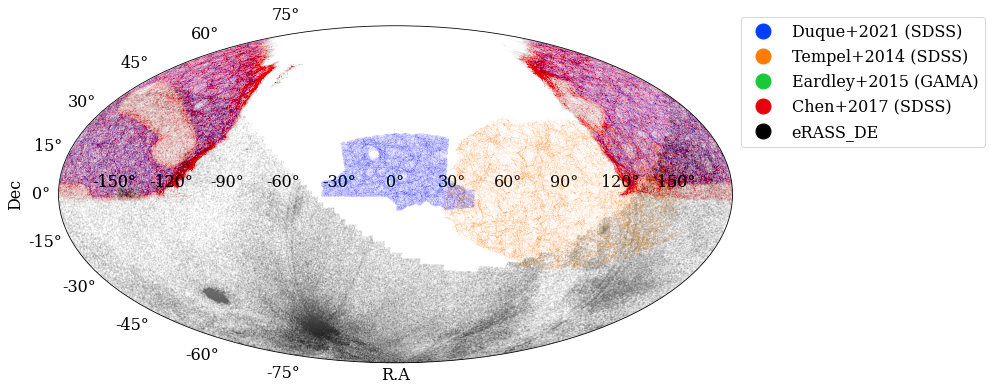

In [98]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="aitoff")

ax, fig = plot_eRASS_skymap(fig, ax, grid_lon_new, grid_lat, alpha=0.05)

ax = plot_obj_duque21.plot_filaments(ax, color=bright_colors[0])
ax = plot_obj_tempel14.plot_filaments(ax, color=bright_colors[1], ms=0.1, alpha=0.5)
ax = plot_obj_eardley15.plot_filaments(ax, color=bright_colors[2])
ax = plot_obj_yenchi17.plot_filaments(ax, color=bright_colors[3], alpha=0.6)

fo.set_labels(ax, "R.A", "Dec", legend=False)

# custom legend
labels=['Duque+2021 (SDSS)', 'Tempel+2014 (SDSS)', 'Eardley+2015 (GAMA)', 'Chen+2017 (SDSS)', 'eRASS_DE']
bright_colors[4]='k'
legend_elements = []
for c, l in zip(bright_colors[:5], labels):
    legend_elements.append(Line2D([0], [0], ls='', marker='o', color=c, label=l, mfc=c, ms=15))
ax.legend(handles=legend_elements, bbox_to_anchor=(1., 1.05))
ax.grid(True)
    
fig.patch.set_facecolor('white')
fig.savefig(f"{plot_obj_duque21.image_dir}/all_catalogues_overplot_without_bkg.png", format='png')

INFO:DoPlotFilaments: Plotting Duque_2021_SDSS on the all sky projection.
INFO:Filaments:Default param 'which_redshifts=lowz'  
INFO:DoPlotFilaments: Plotting Tempel_2014_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_properties.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_point_properties.txt']
INFO:DoPlotFilaments: Plotting Eardley_2015_GAMA on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Eardley_2015_GAMA/GeometricGrid.fits']
INFO:DoPlotFilaments: Plotting Yen_Chi_2017_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Yen_Chi_2017_SDSS/dr12_FMaps_full.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Yen_Chi_2017_SDSS/

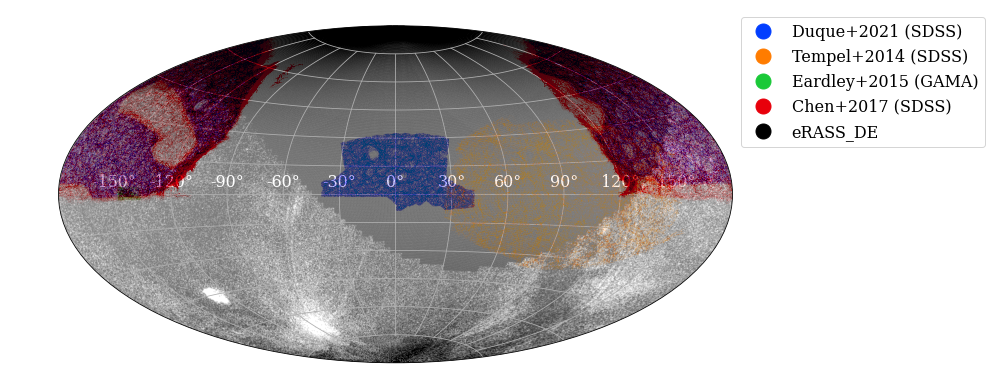

In [105]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="aitoff")


ax = plot_obj_duque21.plot_filaments(ax, color=bright_colors[0])
ax = plot_obj_tempel14.plot_filaments(ax, color=bright_colors[1], ms=0.1, alpha=0.5)
ax = plot_obj_eardley15.plot_filaments(ax, color=bright_colors[2])
ax = plot_obj_yenchi17.plot_filaments(ax, color=bright_colors[3], alpha=0.6)
ax, fig = plot_eRASS_skymap(fig, ax, grid_lon_new, grid_lat, alpha=0.05, cmap='Greys_r')

fo.set_labels(ax, "R.A", "Dec", legend=False)

# custom legend
labels=['Duque+2021 (SDSS)', 'Tempel+2014 (SDSS)', 'Eardley+2015 (GAMA)', 'Chen+2017 (SDSS)', 'eRASS_DE']
bright_colors[4]='k'
legend_elements = []
for c, l in zip(bright_colors[:5], labels):
    legend_elements.append(Line2D([0], [0], ls='', marker='o', color=c, label=l, mfc=c, ms=15))
ax.legend(handles=legend_elements, bbox_to_anchor=(1., 1.05))
ax.grid(True)
    
set_as_white(ax)
fig.savefig(f"{plot_obj_duque21.image_dir}/all_catalogues_overplot_without_bkg_black_bkg.png", format='png')